## 1. Cài thư viện

In [1]:
!pip install transformers datasets sentencepiece huggingface_hub underthesea -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 61.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.2 MB/s eta 0:00:00


## 2. Import & GPU

In [2]:
import os, re, time, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'
NUM_WORKERS = 2 if os.cpu_count() and os.cpu_count() > 2 else 0

print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Workers: {NUM_WORKERS} | Pin memory: {PIN_MEMORY}')


Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB
Workers: 2 | Pin memory: True


## 3. Hyperparameters

In [3]:
MODEL_NAME   = 'vinai/phobert-base'
MAX_LEN      = 128
BATCH_SIZE   = 32
NUM_EPOCHS   = 8

LR           = 1e-5
HEAD_LR      = 5e-5
WARMUP_RATIO = 0.06

DROPOUT      = 0.4
PATIENCE     = 2

NUM_CLASSES  = 2
LABEL_NAMES  = ['NON-HATE', 'HATE']

CNN_FILTERS      = 128
CNN_KERNEL_SIZES = (2, 3, 4)

CKPT_NAME  = 'best_phobert_cnn_vozhsd.pt'
PLOT_TITLE = 'PhoBERT + CNN — VOZ-HSD'

SAMPLE_SIZE  = 100_000
RANDOM_STATE = 42


## 4. Load Dataset

In [4]:
from kaggle_secrets import UserSecretsClient
from datasets import load_dataset
import huggingface_hub

secret_label = "HF_TOKEN"
secret_value = UserSecretsClient().get_secret(secret_label)
huggingface_hub.login(token=secret_value, add_to_git_credential=False)

# VOZ-HSD chỉ có split "train" — stratified sample 100k, giữ tỉ lệ class tự nhiên
ds      = load_dataset("tarudesu/VOZ-HSD", split="train")
full_df = ds.to_pandas()[["texts", "labels"]]
full_df = full_df.rename(columns={"texts": "free_text", "labels": "label_id"})

sampled_df = (
    full_df
    .groupby("label_id", group_keys=False)
    .apply(lambda g: g.sample(frac=SAMPLE_SIZE / len(full_df), random_state=RANDOM_STATE))
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(f"Full dataset : {len(full_df):,} rows")
print(f"Sampled      : {len(sampled_df):,} rows")
print()
print("Tỉ lệ class trong full dataset:")
print(full_df["label_id"].value_counts(normalize=True).sort_index().rename({0: "NON-HATE", 1: "HATE"}).round(4))
print()
print("Tỉ lệ class sau sampling:")
print(sampled_df["label_id"].value_counts(normalize=True).sort_index().rename({0: "NON-HATE", 1: "HATE"}).round(4))


README.md: 0.00B [00:00, ?B/s]

data.csv:   0%|          | 0.00/1.89G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10747733 [00:00<?, ? examples/s]

Full dataset : 10,747,733 rows
Sampled      : 100,000 rows

Tỉ lệ class trong full dataset:
label_id
NON-HATE    0.9456
HATE        0.0544
Name: proportion, dtype: float64

Tỉ lệ class sau sampling:
label_id
NON-HATE    0.9456
HATE        0.0544
Name: proportion, dtype: float64


/tmp/ipykernel_57/1024711809.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=SAMPLE_SIZE / len(full_df), random_state=RANDOM_STATE))


## 5. Label Mapping

In [5]:
# CLEAN=0 → NON-HATE=0, HATE=1 → HATE=1 (giữ nguyên giá trị)
label_map = {0: 'NON-HATE', 1: 'HATE'}

n       = len(sampled_df)
n_train = int(n * 0.8)
n_val   = int(n * 0.1)

train_df = sampled_df.iloc[:n_train].reset_index(drop=True)
val_df   = sampled_df.iloc[n_train:n_train+n_val].reset_index(drop=True)
test_df  = sampled_df.iloc[n_train+n_val:].reset_index(drop=True)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print()
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = df['label_id'].value_counts().sort_index().rename(label_map)
    print(f"  {name}: {dist.to_dict()}")
train_df.head(3)


Train: 80,000 | Val: 10,000 | Test: 10,000

  Train: {'NON-HATE': 75646, 'HATE': 4354}
  Val: {'NON-HATE': 9430, 'HATE': 570}
  Test: {'NON-HATE': 9486, 'HATE': 514}


,free_text,label_id
0,ED của the cat return đó,0
1,Thì như quán thường thôi fen. Vào hét to cho l...,0
2,"mới nghỉ việc, ôn tập phỏng vấn AI Engineer ho...",0


## 6. Tiền xử lý văn bản

In [6]:
from underthesea import word_tokenize

TEENCODE_MAP = {
    'ko': 'không', 'kh': 'không', 'khong': 'không', 'kg': 'không',
    'hok': 'không', 'hk': 'không', 'hem': 'không', 'kô': 'không',
    'chx': 'chưa', 'chua': 'chưa',
    'r': 'rồi', 'rui': 'rồi', 'ròi': 'rồi', 'oy': 'rồi', 'uj': 'rồi',
    'mk': 'mình', 'mik': 'mình', 'mh': 'mình',
    'tui': 'tôi', 'tau': 'tao',
    'may': 'mày', 'mi': 'mày',
    'bn': 'bạn', 'ban': 'bạn',
    'no': 'nó', 'mng': 'mọi người', 'mn': 'mọi người', 'ae': 'anh em',
    'dc': 'được', 'đc': 'được', 'dk': 'được', 'đk': 'được',
    'đươc': 'được', 'duoc': 'được',
    'vs': 'với', 'voi': 'với',
    'j': 'gì', 'zì': 'gì', 'zi': 'gì',
    'ntn': 'như thế nào', 'nso': 'như sao',
    'biet': 'biết', 'bit': 'biết', 'hieu': 'hiểu', 'nghi': 'nghĩ',
    'muon': 'muốn', 'hoac': 'hoặc', 'neu': 'nếu', 'nen': 'nên',
    'giet': 'giết', 'chui': 'chửi', 'danh': 'đánh',
    'nx': 'nhưng', 'nhg': 'nhưng', 'nhưg': 'nhưng', 'nma': 'nhưng mà',
    'cx': 'cũng', 'cg': 'cũng', 'cung': 'cũng', 'cũg': 'cũng',
    'ms': 'mới', 'boi': 'bởi',
    'oke': 'ok', 'okie': 'ok', 'okê': 'ok', 'okey': 'ok',
    'uh': 'ừ', 'uk': 'ừ', 'uhm': 'ừ',
    'yep': 'đúng', 'yup': 'đúng',
    'haha': 'haha', 'hehe': 'hehe', 'hihi': 'hehe', 'huhu': 'buồn',
    'haiz': 'thở dài', 'haizz': 'thở dài',
    'wtf': 'cái gì vậy', 'omg': 'ôi trời',
    'lol': 'buồn cười', 'lmao': 'buồn cười',
    'fck': 'chửi thề', 'fk': 'chửi thề', 'gg': 'xong rồi', 'ez': 'dễ',
    'bt': 'bình thường', 'bth': 'bình thường',
    'noob': 'tệ', 'nub': 'tệ',
    'xàm': 'vô nghĩa', 'nhảm': 'vô nghĩa',
    'pro': 'giỏi',
    'vl': 'vãi lồn', 'vcl': 'vãi cái lồn', 'vkl': 'vãi kép lồn',
    'vll': 'vãi lồn', 'vleu': 'vãi lồn', 'vloz': 'vãi lồn',
    'dm': 'đụ má', 'đm': 'đụ má', 'd.m': 'đụ má', 'đ.m': 'đụ má',
    'đmm': 'đụ má mày', 'dmm': 'đụ má mày',
    'đtm': 'địt mẹ', 'dtm': 'địt mẹ',
    'cl': 'cái lồn', 'lon': 'lồn', 'loz': 'lồn', 'l0n': 'lồn',
    'đéo': 'không', 'deo': 'không', 'éo': 'không',
    'cc': 'cái con', 'thg': 'thằng',
    'ngu': 'ngu', 'đần': 'đần độn', 'khùng': 'điên', 'dien': 'điên',
    'cút': 'cút', 'cut': 'cút',
    'câm': 'câm miệng', 'im mồm': 'câm miệng',
    'fb': 'facebook', 'yt': 'youtube', 'tt': 'tiktok', 'zl': 'zalo',
    'ig': 'instagram', 'cmt': 'bình luận', 'rep': 'trả lời',
    'vn': 'việt nam', 'hn': 'hà nội', 'hcm': 'hồ chí minh', 'sg': 'sài gòn',
    'iu': 'yêu', 'ieu': 'yêu',
}


def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\b0[0-9]{9,10}\b', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [TEENCODE_MAP.get(w, w) for w in text.split()]
    return ' '.join(words)


def preprocess(text: str) -> str:
    text = normalize_text(text)
    if not text:
        return ''
    try:
        return word_tokenize(text, format='text')
    except Exception:
        return text


sample = 'mày ko hiểu gì hết, ngu vcl!!'
print(f'Original : {sample}')
print(f'Processed: {preprocess(sample)}')


Original : mày ko hiểu gì hết, ngu vcl!!
Processed: mày không hiểu gì hết ngu_vãi cái lồn


## 7. Áp dụng tiền xử lý

In [7]:
print("Preprocessing texts...")
for df, name in [(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]:
    df['text_processed'] = df['free_text'].apply(preprocess)
    print(f'  {name}: done')

print()
print("Sample:")
for _, row in train_df.sample(3, random_state=42).iterrows():
    lbl = label_map[row['label_id']]
    print(f'  [{lbl:>8}] {row["free_text"][:50]}')
    print(f'           -> {row["text_processed"][:50]}')


Preprocessing texts...
  Train: done
  Val: done
  Test: done

Sample:
  [NON-HATE] h vẫn cần 1 tiền vệ thoát bóng chuyền dài thì đỡ c
           -> h vẫn cần 1 tiền_vệ thoát bóng_chuyền dài thì đỡ c
  [NON-HATE] Nếu không có bằng chứng hay biên bản ghi lại việc 
           -> nếu không có bằng_chứng hay biên_bản ghi lại việc 
  [NON-HATE] nghe nói là có vozer nào đó tình cờ mua đồ gì đấy 
           -> nghe nói là có vozer nào đó tình_cờ mua đồ gì đấy 


## 8. PhoBERT Tokenizer

In [8]:
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

print('Loading PhoBERT tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Vocab size: {tokenizer.vocab_size:,}')

sample = 'mày ko hiểu gì hết, ngu vcl!!'
print(f'\nOriginal : {sample}')
print(f'Processed: {preprocess(sample)}')
print(f'Tokens   : {tokenizer.tokenize(preprocess(sample))}')


Loading PhoBERT tokenizer...


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size: 64,000

Original : mày ko hiểu gì hết, ngu vcl!!
Processed: mày không hiểu gì hết ngu_vãi cái lồn
Tokens   : ['mày', 'không', 'hiểu', 'gì', 'hết', 'ngu_@@', 'vãi', 'cái', 'l@@', 'ồn']


## 9. Dataset & DataLoader

In [9]:
class HSDDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.texts = df['text_processed'].fillna('').tolist()
        self.labels = df['label_id'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds = HSDDataset(train_df, tokenizer)
val_ds   = HSDDataset(val_df, tokenizer)
test_ds  = HSDDataset(test_df, tokenizer)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')


Train batches: 2500 | Val: 313 | Test: 313


## 10. Model PhoBERT + CNN


In [10]:
class PhoBERTCNN(nn.Module):
    def __init__(
        self,
        model_name,
        num_classes,
        num_filters=CNN_FILTERS,
        kernel_sizes=CNN_KERNEL_SIZES,
        dropout=DROPOUT
    ):
        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.kernel_sizes = kernel_sizes

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=hidden_size,
                out_channels=num_filters,
                kernel_size=k
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # [batch, seq_len, hidden_size]
        x = outputs.last_hidden_state

        # [batch, hidden_size, seq_len]
        x = x.transpose(1, 2)

        pooled_outputs = []

        for conv, k in zip(self.convs, self.kernel_sizes):
            # [batch, num_filters, conv_seq_len]
            conv_out = torch.relu(conv(x))

            # Tạo mask hợp lệ cho từng cửa sổ CNN
            # Window chỉ hợp lệ nếu trong kernel không toàn PAD
            valid_mask = F.max_pool1d(
                attention_mask.float().unsqueeze(1),
                kernel_size=k,
                stride=1
            ).bool()

            # Không cho vùng PAD thắng max pooling
            conv_out = conv_out.masked_fill(~valid_mask, -1e4)

            pooled = torch.max(conv_out, dim=2).values
            pooled_outputs.append(pooled)

        x = torch.cat(pooled_outputs, dim=1)
        x = self.dropout(x)

        return self.fc(x)


print('Loading PhoBERT + CNN model...')
model = PhoBERTCNN(MODEL_NAME, NUM_CLASSES).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')
print(f'CNN kernels     : {CNN_KERNEL_SIZES} | Filters/kernel: {CNN_FILTERS}')


Loading PhoBERT + CNN model...


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Total params    : 135,884,162
Trainable params: 135,884,162
CNN kernels     : (2, 3, 4) | Filters/kernel: 128


## 11. Loss, Optimizer & Scheduler

In [11]:
label_counts = train_df['label_id'].value_counts().sort_index().values
class_weights = torch.tensor(
    len(train_df) / (NUM_CLASSES * label_counts),
    dtype=torch.float32,
    device=DEVICE
)
print('Class weights:', class_weights.detach().cpu().numpy().round(3))

# criterion = nn.CrossEntropyLoss(weight=class_weights)

criterion_train = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)

criterion_eval = nn.CrossEntropyLoss()
# optimizer = optim.AdamW([
#     {'params': model.bert.parameters(), 'lr': LR},
#     {'params': list(model.convs.parameters()) + list(model.fc.parameters()), 'lr': HEAD_LR},
# ], weight_decay=0.01)

no_decay = ['bias', 'LayerNorm.weight']

bert_decay = []
bert_no_decay = []

for name, param in model.bert.named_parameters():
    if not param.requires_grad:
        continue
    if any(nd in name for nd in no_decay):
        bert_no_decay.append(param)
    else:
        bert_decay.append(param)

head_params = list(model.convs.parameters()) + list(model.fc.parameters())

optimizer = optim.AdamW(
    [
        {'params': bert_decay, 'lr': LR, 'weight_decay': 0.01},
        {'params': bert_no_decay, 'lr': LR, 'weight_decay': 0.0},
        {'params': head_params, 'lr': HEAD_LR, 'weight_decay': 0.01},
    ]
)

total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')
print(f'Total steps: {total_steps} | Warmup: {warmup_steps}')


Class weights: [0.529 9.187]
Total steps: 20000 | Warmup: 1200


## 12. Training

In [12]:
def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = total_correct = total_n = 0

    for batch in loader:
        ids = batch['input_ids'].to(DEVICE, non_blocking=PIN_MEMORY)
        mask = batch['attention_mask'].to(DEVICE, non_blocking=PIN_MEMORY)
        y = batch['label'].to(DEVICE, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            logits = model(ids, mask)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        preds = logits.argmax(1)
        total_loss += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total_n += y.size(0)

    return total_loss / total_n, total_correct / total_n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = total_correct = total_n = 0
    all_preds, all_labels = [], []

    for batch in loader:
        ids = batch['input_ids'].to(DEVICE, non_blocking=PIN_MEMORY)
        mask = batch['attention_mask'].to(DEVICE, non_blocking=PIN_MEMORY)
        y = batch['label'].to(DEVICE, non_blocking=PIN_MEMORY)

        with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            logits = model(ids, mask)
            loss = criterion(logits, y)

        preds = logits.argmax(1)

        total_loss += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total_n += y.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )

    return total_loss / total_n, total_correct / total_n, macro_f1


In [13]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_f1, best_epoch, patience_counter = -1.0, 0, 0

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6} | {'LR':>8} | {'Time':>6}")
print('-' * 88)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    # tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, scaler)
    # vl_loss, vl_acc, vl_f1 = evaluate(model, val_loader, criterion)

    tr_loss, tr_acc = train_epoch(
    model, train_loader, optimizer, scheduler, criterion_train, scaler
    )
    
    vl_loss, vl_acc, vl_f1 = evaluate(
        model, val_loader, criterion_eval
    )
    elapsed = time.time() - t0
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(vl_f1)

    flag = ''
    if vl_f1 > best_f1:
        best_f1, best_epoch = vl_f1, epoch
        torch.save(model.state_dict(), CKPT_NAME)
        patience_counter = 0
        flag = ' saved'
    else:
        patience_counter += 1

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {vl_loss:>8.4f} | {vl_acc:>7.4f} | {vl_f1:>6.4f} | {current_lr:>8.2e} | {elapsed:>5.1f}s{flag}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nBest Val F1 = {best_f1:.4f} at epoch {best_epoch}')


 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1 |       LR |   Time
----------------------------------------------------------------------------------------
     1 |     0.7166 |    0.7731 |   0.4716 |  0.9202 | 0.7554 | 9.31e-06 | 566.3s saved
     2 |     0.6469 |    0.9225 |   0.5518 |  0.8958 | 0.7237 | 7.98e-06 | 566.4s
     3 |     0.6186 |    0.9492 |   0.4678 |  0.9414 | 0.7953 | 6.65e-06 | 567.3s saved
     4 |     0.5949 |    0.9696 |   0.4883 |  0.9474 | 0.8042 | 5.32e-06 | 566.8s saved
     5 |     0.5744 |    0.9800 |   0.4515 |  0.9594 | 0.8178 | 3.99e-06 | 566.8s saved
     6 |     0.5585 |    0.9855 |   0.4894 |  0.9533 | 0.8105 | 2.66e-06 | 566.6s
     7 |     0.5472 |    0.9895 |   0.4537 |  0.9615 | 0.8234 | 1.33e-06 | 567.1s saved
     8 |     0.5400 |    0.9916 |   0.4502 |  0.9610 | 0.8177 | 0.00e+00 | 566.8s

Best Val F1 = 0.8234 at epoch 7


## 13. Training Curves

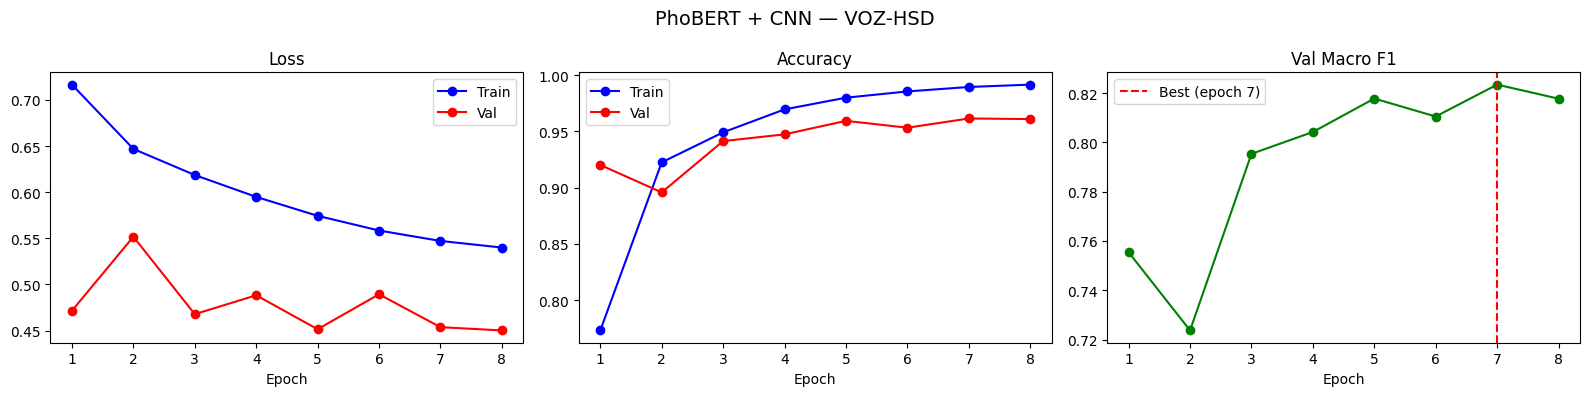

In [14]:
n            = len(history['train_loss'])
epochs_range = range(1, n + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_range, history['val_f1'], 'g-o')
axes[2].axvline(best_epoch, color='red', linestyle='--', label=f'Best (epoch {best_epoch})')
axes[2].set_title('Val Macro F1'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.suptitle(PLOT_TITLE, fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


## 14. Đánh giá Test Set

In [15]:
model.load_state_dict(torch.load(CKPT_NAME, map_location=DEVICE))

@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    for batch in loader:
        ids = batch['input_ids'].to(DEVICE, non_blocking=PIN_MEMORY)
        mask = batch['attention_mask'].to(DEVICE, non_blocking=PIN_MEMORY)
        logits = model(ids, mask)

        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(batch['label'].numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = get_predictions(model, test_loader)

print('Classification Report — Test Set')
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4))


Classification Report — Test Set
              precision    recall  f1-score   support

    NON-HATE     0.9826    0.9775    0.9801      9486
        HATE     0.6217    0.6809    0.6500       514

    accuracy                         0.9623     10000
   macro avg     0.8021    0.8292    0.8150     10000
weighted avg     0.9641    0.9623    0.9631     10000



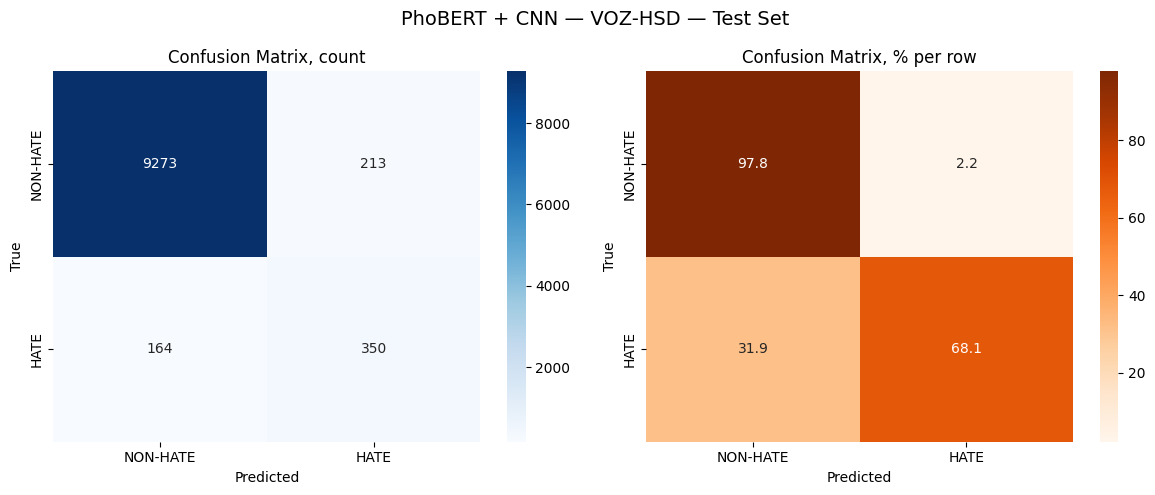

In [16]:
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
axes[0].set_title('Confusion Matrix, count')
axes[1].set_title('Confusion Matrix, % per row')
for ax in axes:
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
plt.suptitle(PLOT_TITLE + ' — Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


## 15. Kiểm chứng nhanh

In [17]:
@torch.no_grad()
def predict(texts):
    model.eval()
    results = []

    for text in texts:
        processed = preprocess(text)
        enc = tokenizer(
            processed,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        ids = enc['input_ids'].to(DEVICE)
        mask = enc['attention_mask'].to(DEVICE)

        logits = model(ids, mask)
        probs = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
        pred_id = int(probs.argmax())

        results.append({
            'text': text,
            'processed': processed,
            'label': LABEL_NAMES[pred_id],
            'scores': {LABEL_NAMES[i]: round(float(p), 4) for i, p in enumerate(probs)},
        })

    return results


TEST_CASES = [
    ('Hôm nay trời đẹp quá, đi chơi thôi!', 'NON-HATE'),
    ('Tụi nó toàn nói nhảm, đúng là quá toxic', 'NON-HATE'),
    ('Đồ ngu, câm miệng lại đi mày', 'NON-HATE'),
    ('Tao ghét cái loại người như mày, xéo đi cho khuất mắt', 'HATE'),
    ('Cảm ơn bạn đã giúp đỡ mình nhé!', 'NON-HATE'),
    ('Tao cảm ơn mày nhiều lắm', 'NON-HATE'),
    ("nguyên cả cái tỉnh này không được khôn lắm",                              "HATE"),
]

correct = 0
for text, expected in TEST_CASES:
    r = predict([text])[0]
    match = 'OK' if r['label'] == expected else 'WRONG'
    correct += int(r['label'] == expected)
    prob_str = ' | '.join([f'{k}: {v:.2f}' for k, v in r['scores'].items()])

    print(f'Input   : {text}')
    print(f'Processed: {r["processed"]}')
    print(f'Expected: {expected}')
    print(f'Pred    : {r["label"]:<10} {match:<6} {prob_str}')
    print()

print(f'Summary: {correct}/{len(TEST_CASES)}  ({correct / len(TEST_CASES) * 100:.0f}%)')


Input   : Hôm nay trời đẹp quá, đi chơi thôi!
Processed: hôm_nay trời đẹp quá đi chơi thôi
Expected: NON-HATE
Pred    : NON-HATE   OK     NON-HATE: 0.69 | HATE: 0.31

Input   : Tụi nó toàn nói nhảm, đúng là quá toxic
Processed: tụi nó toàn nói vô_nghĩa đúng là quá toxic
Expected: NON-HATE
Pred    : HATE       WRONG  NON-HATE: 0.00 | HATE: 1.00

Input   : Đồ ngu, câm miệng lại đi mày
Processed: đồ ngu câm_miệng miệng lại đi mày
Expected: NON-HATE
Pred    : HATE       WRONG  NON-HATE: 0.00 | HATE: 1.00

Input   : Tao ghét cái loại người như mày, xéo đi cho khuất mắt
Processed: tao ghét cái loại người như mày xéo đi cho khuất mắt
Expected: HATE
Pred    : HATE       OK     NON-HATE: 0.00 | HATE: 1.00

Input   : Cảm ơn bạn đã giúp đỡ mình nhé!
Processed: cảm_ơn bạn đã giúp_đỡ mình nhé
Expected: NON-HATE
Pred    : NON-HATE   OK     NON-HATE: 0.69 | HATE: 0.31

Input   : Tao cảm ơn mày nhiều lắm
Processed: tao cảm_ơn mày nhiều lắm
Expected: NON-HATE
Pred    : NON-HATE   OK     NON-HATE: 0.68 

## 16. Lưu model

In [19]:
import shutil

os.makedirs('outputs', exist_ok=True)

# Lưu checkpoint
shutil.copy(CKPT_NAME, f'outputs/{CKPT_NAME}')

# Lưu config
config = {
    'model_name'   : MODEL_NAME,
    'architecture' : 'PhoBERT + CNN',
    'dataset'      : 'VOZ-HSD (100k stratified)',
    'max_len'      : MAX_LEN,
    'num_classes'  : NUM_CLASSES,
    'label_names'  : LABEL_NAMES,
    'cnn_filters'  : CNN_FILTERS,
    'cnn_kernel_sizes': list(CNN_KERNEL_SIZES),
    'dropout'      : DROPOUT,
    'lr_phobert'   : LR,
    'lr_cnn_head'  : HEAD_LR,
    'best_epoch'   : int(best_epoch),
    'best_val_f1'  : round(float(best_f1), 4),
    'test_macro_f1': round(float(f1_score(y_true, y_pred, average='macro')), 4),
    'test_f1_hate' : round(float(f1_score(y_true, y_pred, labels=[1], average='macro')), 4),
}
with open('outputs/config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"Test Macro F1 : {config['test_macro_f1']:.4f}")
print(f"Test F1 HATE  : {config['test_f1_hate']:.4f}")
print(f"Checkpoint    : outputs/{CKPT_NAME}")
print(f"Config        : outputs/config.json")


Test Macro F1 : 0.8150
Test F1 HATE  : 0.6500
Checkpoint    : outputs/best_phobert_cnn_vozhsd.pt
Config        : outputs/config.json
